In [1]:
%pip install -U -q numpy pandas wfdb matplotlib notebook scikit-learn PyWavelets plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.linear_model import LinearRegression

import funkcje
from processor import Signal, ICP_ABP_Processor

#MAJA I MANIA DETEKCJA EVENTÓW

In [2]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from processor import Signal, ICP_ABP_Processor
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Sekcja wczytwania


In [3]:
# --- 1. KLASA PRZETWARZAJĄCA ZGODNIE ZE SCHEMATEM BLOKOWYM ---
class ICP_ABP_Processor:
    def __init__(self, channel_icp, channel_abp, sampling_freq, record_name):
        self.channel_icp = Signal(channel_icp, sampling_freq, name="ICP")
        self.channel_abp = Signal(channel_abp, sampling_freq, name="ABP")
        self.fs = sampling_freq
        self.final_segments = []
        self.df = None
        self.total_events_count = 0 
        self.record_name = record_name

    def process_all(self):
        print("Uruchamiam szybkie przetwarzanie wektorowe Pandas...")
        
        # Etapy 1-3: Podział na minuty i obliczenie wartości średnich (MICP i MABP)
        samples_per_min = int(self.fs * 60)
        full_mins = len(self.channel_icp.data) // samples_per_min
        
        icp_matrix = self.channel_icp.data[:full_mins * samples_per_min].reshape(full_mins, samples_per_min)
        abp_matrix = self.channel_abp.data[:full_mins * samples_per_min].reshape(full_mins, samples_per_min)
        
        self.df = pd.DataFrame({
            'MICP': icp_matrix.mean(axis=1),
            'MABP': abp_matrix.mean(axis=1)
        })
        
        # Etap 4: Detekcja i usunięcie zakłóceń (>50 mmHg)
        self.df['is_valid'] = self.df['MICP'] <= 50
        
        # Etap 5: Detekcja zdarzeń (>25 mmHg przez co najmniej 5 min)
        self.df['event_condition'] = self.df['is_valid'] & (self.df['MICP'] > 20)
        self.df['block_id'] = (~self.df['event_condition']).cumsum()
        
        event_blocks = self.df[self.df['event_condition']].groupby('block_id').size()
        valid_event_blocks = event_blocks[event_blocks >= 5].index
        
        self.total_events_count = len(valid_event_blocks)
        
        # Oznaczamy minuty, które wchodzą w skład poprawnych eventów (potrzebne do wykresu)
        self.df['is_event'] = self.df['event_condition'] & self.df['block_id'].isin(valid_event_blocks)
        
        # Etap 6: Podział na segmenty (1 h prawidłowego sygnału przed + zdarzenie)
        for block in valid_event_blocks:
            event_minutes = self.df[(self.df['block_id'] == block) & self.df['event_condition']].index
            event_start = event_minutes.min()
            event_end = event_minutes.max()
            
            # Musimy mieć przynajmniej 60 minut sygnału przed startem
            if event_start >= 60:
                pre_event_window = self.df.loc[event_start - 60 : event_start - 1, 'is_valid']
                # Jeśli cała godzina przed jest prawidłowa (czysta od zakłóceń)
                if pre_event_window.all():
                    self.final_segments.append({
                        'pre_event_start_min': event_start - 60,
                        'event_start_min': event_start,
                        'event_end_min': event_end,
                        'duration_min': (event_end - event_start) + 1
                    })
            with open(f'DetectedEvents-{self.record_name}.txt','w') as f:
                for line in self.final_segments:
                    f.write(f'{line}\n')

        total_seconds = len(self.channel_icp.data) / self.fs
        print("\n" + "="*50)
        print(f" ZAKOŃCZONO ANALIZĘ")
        print("="*50)
        print(f"  * Czas trwania sygnału: {total_seconds:.1f} s ({total_seconds/3600:.2f} h)")
        print(f"  * Liczba wykrytych zdarzeń (eventów): {self.total_events_count}")
        print(f"  * Liczba zaakceptowanych segmentów klinicznych: {len(self.final_segments)}")
        print("="*50 + "\n")

In [4]:

# =========================================================================
# 2. WCZYTYWANIE REKORDU (WFDB)
# =========================================================================
data_dir = 'charis-database-1.0.0'  
record_name = 'charis6'           

os.makedirs(data_dir, exist_ok=True)
local_path = os.path.join(data_dir, record_name)

record = wfdb.rdrecord(local_path)
signals = record.p_signal  
fs = record.fs  

channel_ABP = signals[:, 0]
channel_ICP = signals[:, 2]

# Uruchomienie obliczeń
processor = ICP_ABP_Processor(channel_ICP, channel_ABP, sampling_freq=fs, record_name=record_name)
#processor.channel_icp.remove_noise(min_val=-1, max_val=100)

total_seconds = len(processor.channel_icp.data) / processor.channel_icp.fs
print(f" Czas trwania sygnału: {total_seconds:.1f} s, ({total_seconds/60:.2f} m) ({total_seconds/3600:.2f} h)")

processor.process_all()

 Czas trwania sygnału: 165599.6 s, (2759.99 m) (46.00 h)
Uruchamiam szybkie przetwarzanie wektorowe Pandas...

 ZAKOŃCZONO ANALIZĘ
  * Czas trwania sygnału: 165599.6 s (46.00 h)
  * Liczba wykrytych zdarzeń (eventów): 12
  * Liczba zaakceptowanych segmentów klinicznych: 11



In [5]:
# 3. GENEROWANIE INTERAKTYWNEGO WYKRESU W STYLU "FIG. 7 EVENT DETECTION"
# =========================================================================

# Przeliczamy indeksy minutowe z ramki DataFrame na godziny dla osi X
time_hours = processor.df.index / 60

# Tworzymy dwa wykresy jeden pod drugim (2 wiersze, 1 kolumna)
fig = make_subplots(
    rows=2, cols=1, 
    subplot_titles=(
        f'<b>Fig. 7 Event detection - {record_name}</b>', 
        '<i>Expanded view of the event</i>'
    ),
    vertical_spacing=0.12  # Odstęp między wykresami
)

# -------------------------------------------------------------------------
# --- WYKRES 1: CAŁOŚĆ (GÓRA - row=1, col=1) ---
# -------------------------------------------------------------------------

# Sygnał główny MICP
fig.add_trace(go.Scatter(
    x=time_hours,
    y=processor.df['MICP'],
    mode='lines',
    name='adjusted mean',
    line=dict(color='limegreen', width=1),
    hovertemplate='<b>Czas:</b> %{x:.2f} h<br><b>MICP:</b> %{y:.2f} mmHg<extra></extra>'
), row=1, col=1)

# Naniesienie linii "quiet period" oraz kółeczek startu dla każdego segmentu
for i, seg in enumerate(processor.final_segments):
    start_h = seg['event_start_min'] / 60
    pre_start_h = seg['pre_event_start_min'] / 60
    y_val = processor.df.loc[seg['event_start_min'], 'MICP']
    
    # Czerwona linia oznaczająca okres ciszy przed zdarzeniem
    # Ukrywamy w legendzie kolejne linie (showlegend=False), żeby nie śmiecić
    fig.add_trace(go.Scatter(
        x=[pre_start_h, start_h],
        y=[y_val, y_val],
        mode='lines',
        name='quiet period',
        line=dict(color='crimson', width=2),
        showlegend=False,
        hoverinfo='skip'  # Linia pomocnicza nie potrzebuje własnego dymka
    ), row=1, col=1)
    
    # Czarne kółeczko oznaczające dokładny początek zdarzenia
    lbl = 'identified event start times' if i == 0 else ""
    fig.add_trace(go.Scatter(
        x=[start_h],
        y=[y_val],
        mode='markers',
        name='identified event start times',
        marker=dict(
            color='rgba(0,0,0,0)',  # Przezroczysty środek (facecolors='none')
            size=10,
            line=dict(color='black', width=1.5)  # Czarna ramka
        ),
        showlegend=(i == 0),  # Pokazujemy w legendzie tylko za pierwszym razem
        hovertemplate='<b>Początek zdarzenia</b><br>Czas: %{x:.2f} h<br>ICP: %{y:.2f} mmHg<extra></extra>'
    ), row=1, col=1)


# -------------------------------------------------------------------------
# --- WYKRES 2: EXPANDED VIEW (DÓŁ - row=2, col=1) ---
# -------------------------------------------------------------------------

if len(processor.final_segments) > 0:
    # Wybieramy pierwszy spełniający warunki segment do przybliżenia
    seg_zoom = processor.final_segments[0]
    
    pad_mins = 40
    zoom_start_min = max(0, seg_zoom['pre_event_start_min'] - pad_mins)
    zoom_end_min = min(len(processor.df) - 1, seg_zoom['event_end_min'] + pad_mins)
    
    # Wycinamy fragment danych do przybliżenia
    df_zoom = processor.df.loc[zoom_start_min:zoom_end_min]
    time_hours_zoom = df_zoom.index / 60
    
    # Zielona linia sygnału w przybliżeniu
    fig.add_trace(go.Scatter(
        x=time_hours_zoom,
        y=df_zoom['MICP'],
        mode='lines',
        name='adjusted mean (zoom)',
        line=dict(color='limegreen', width=2),
        hovertemplate='<b>Czas:</b> %{x:.2f} h<br><b>MICP:</b> %{y:.2f} mmHg<extra></extra>'
    ), row=2, col=1)
    
    # Współrzędne czasowe dla linii statusu
    h_pre_start = seg_zoom['pre_event_start_min'] / 60
    h_event_start = seg_zoom['event_start_min'] / 60
    h_event_end = seg_zoom['event_end_min'] / 60
    
    # Czerwona pozioma linia: "low ICP before event" na wysokości 20 mmHg (zgodnie z Twoim kodem)
    fig.add_trace(go.Scatter(
        x=[h_pre_start, h_event_start],
        y=[20, 20],
        mode='lines',
        name='low ICP before event',
        line=dict(color='crimson', width=3),
        hovertemplate='Low ICP threshold period<extra></extra>'
    ), row=2, col=1)
    
    # Niebieska pozioma linia: "high ICP after event" na wysokości 20 mmHg
    fig.add_trace(go.Scatter(
        x=[h_event_start, h_event_end],
        y=[20, 20],
        mode='lines',
        name='high ICP after event',
        line=dict(color='dodgerblue', width=3.5),
        hovertemplate='High ICP event duration<extra></extra>'
    ), row=2, col=1)
    
    # Czarne kółeczko w punkcie startu na wykresie przybliżonym
    y_zoom_start = processor.df.loc[seg_zoom['event_start_min'], 'MICP']
    fig.add_trace(go.Scatter(
        x=[h_event_start],
        y=[y_zoom_start],
        mode='markers',
        name='Zoom Event Start',
        marker=dict(
            color='rgba(0,0,0,0)',
            size=12,
            line=dict(color='black', width=2)
        ),
        showlegend=False,
        hovertemplate='<b>Punkt krytyczny</b><br>Czas: %{x:.2f} h<extra></extra>'
    ), row=2, col=1)

else:
    # Adnotacja awaryjna (zamiast ax2.text)
    fig.add_annotation(
        text="Brak segmentów klinicznych spełniających<br>kryterium 1h czystego sygnału przed eventem.",
        xref="x2", yref="y2",
        x=0.5, y=0.5, showarrow=False,
        font=dict(size=14, color="gray")
    )

# -------------------------------------------------------------------------
# --- KONFIGURACJA UKŁADU, OSI I INTERAKCJI (LAYOUT) ---
# -------------------------------------------------------------------------

fig.update_layout(
    template='plotly_white',
    hovermode='x unified',      # Łączenie etykiet pod kursorem myszy
    dragmode='zoom',            # Interaktywne powiększanie boksem
    width=1500,                 # Szerokość okna wykresu
    height=900,                 # Wysokość dostosowana do dwóch osi pionowych
    legend=dict(
        orientation="h",        # Pozioma legenda na górze dla oszczędności miejsca
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Konfiguracja Osi X i Y dla WYKRESU 1 (Góra)
fig.update_xaxes(
    title_text='Time in hours',
    gridcolor='rgba(200, 200, 200, 0.2)',
    showspikes=True, spikemode='across', spikethickness=1, spikedash='dash',
    row=1, col=1
)
fig.update_yaxes(
    title_text='mmHg',
    range=[0, 100],  # Sztywny zakres z ax1.set_ylim(0, 100)
    gridcolor='rgba(200, 200, 200, 0.2)',
    row=1, col=1
)

# Konfiguracja Osi X i Y dla WYKRESU 2 (Dół)
fig.update_xaxes(
    title_text='Time in hours',
    gridcolor='rgba(200, 200, 200, 0.2)',
    showspikes=True, spikemode='across', spikethickness=1, spikedash='dash',
    row=2, col=1
)
fig.update_yaxes(
    title_text='mmHg',
    gridcolor='rgba(200, 200, 200, 0.2)',
    row=2, col=1
)

# Wyświetlenie wykresu
fig.show()

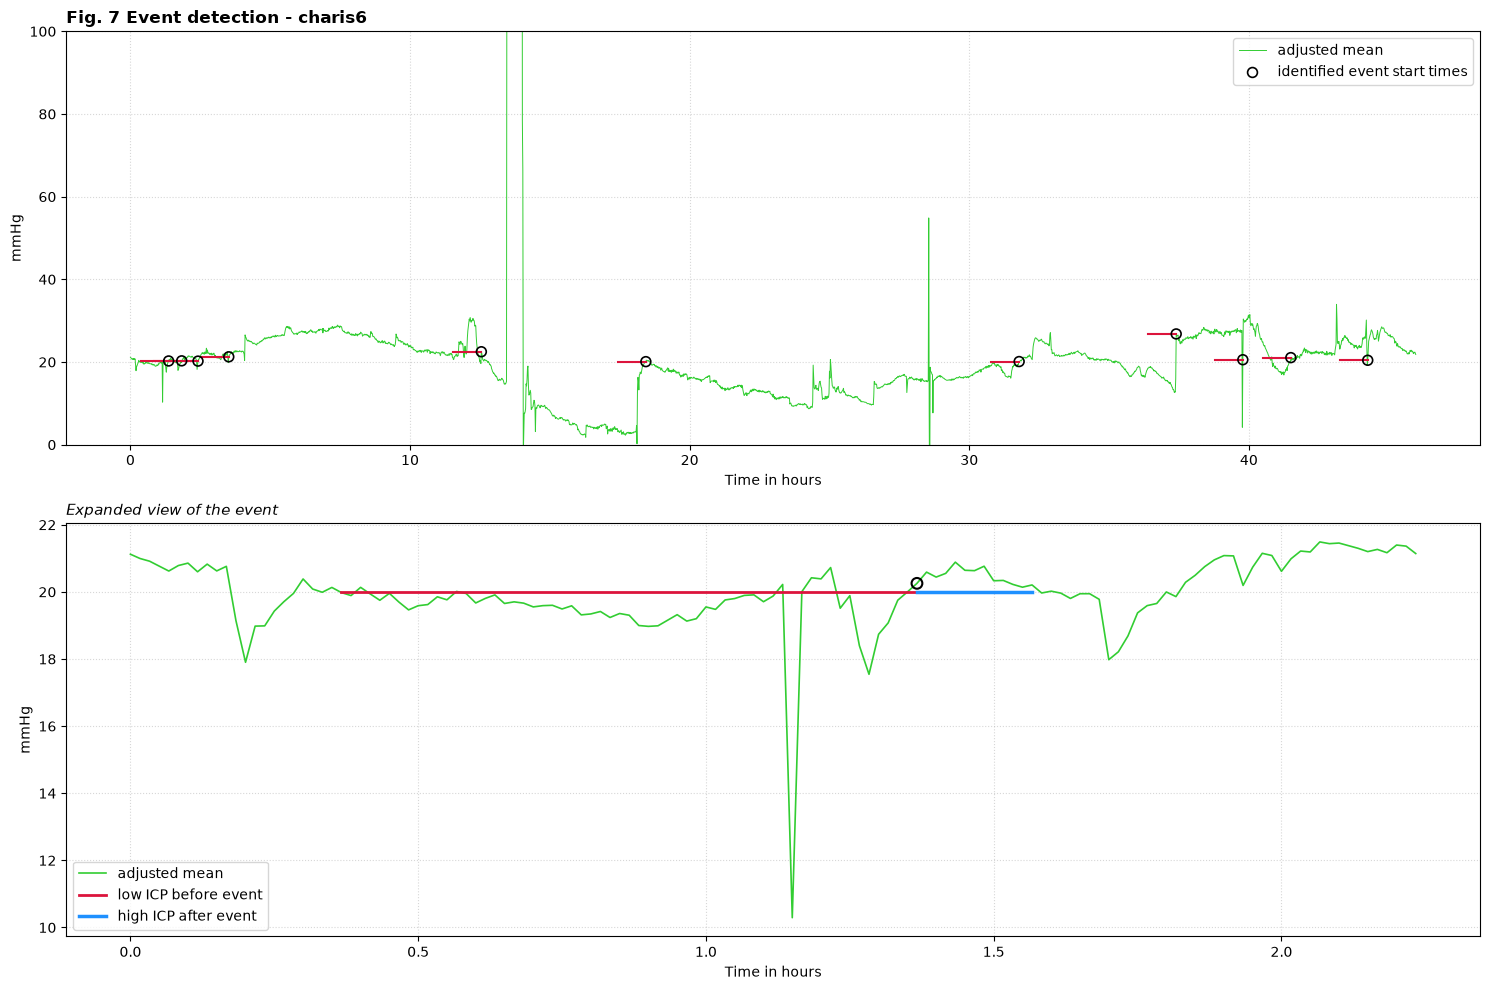

In [6]:

# =========================================================================
# 3. GENEROWANIE WYKRESU W STYLU "FIG. 7 EVENT DETECTION"
# =========================================================================
# Tworzymy dwa wykresy jeden pod drugim (Główny oraz Przybliżenie)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Przeliczamy indeksy minutowe z ramki DataFrame na godziny dla osi X
time_hours = processor.df.index / 60

# --- WYKRES 1: CAŁOŚĆ (GÓRA) ---
ax1.plot(time_hours, processor.df['MICP'], color='limegreen', linewidth=0.7, label='adjusted mean')

# Naniesienie kółeczek i linii "quiet period" dla każdego segmentu klinicznego
for i, seg in enumerate(processor.final_segments):
    start_h = seg['event_start_min'] / 60
    pre_start_h = seg['pre_event_start_min'] / 60
    # Pobieramy wartość ICP w minucie startu, aby na tej wysokości narysować linię
    y_val = processor.df.loc[seg['event_start_min'], 'MICP']
    
    # Czerwona linia oznaczająca okres ciszy przed zdarzeniem (1 godzina)
    ax1.plot([pre_start_h, start_h], [y_val, y_val], color='crimson', linewidth=1.5, zorder=3)
    
    # Czarne kółeczko oznaczające dokładny początek zdarzenia
    # Używamy label tylko dla pierwszego elementu, żeby nie dublować legendy
    lbl = 'identified event start times' if i == 0 else ""
    ax1.scatter(start_h, y_val, facecolors='none', edgecolors='black', s=50, linewidth=1.2, zorder=4, label=lbl)

ax1.set_title(f'Fig. 7 Event detection - {record_name}', fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel('Time in hours')
ax1.set_ylabel('mmHg')
ax1.set_ylim(0, 100)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(loc='upper right')


# --- WYKRES 2: EXPANDED VIEW (DÓŁ) ---
if len(processor.final_segments) > 0:
    # Do prezentacji przybliżenia wybieramy pierwszy spełniający warunki segment
    seg_zoom = processor.final_segments[0]
    
    # Określamy granice przybliżenia: 40 minut przed okresem ciszy i 40 minut po evencie
    pad_mins = 40
    zoom_start_min = max(0, seg_zoom['pre_event_start_min'] - pad_mins)
    zoom_end_min = min(len(processor.df) - 1, seg_zoom['event_end_min'] + pad_mins)
    
    # Wycinamy fragment danych do przybliżenia
    df_zoom = processor.df.loc[zoom_start_min:zoom_end_min]
    time_hours_zoom = df_zoom.index / 60
    
    # Rysujemy zieloną linię sygnału w przybliżeniu
    ax2.plot(time_hours_zoom, df_zoom['MICP'], color='limegreen', linewidth=1.2, label='adjusted mean')
    
    # Wyznaczamy współrzędne czasowe w godzinach dla linii statusu
    h_pre_start = seg_zoom['pre_event_start_min'] / 60
    h_event_start = seg_zoom['event_start_min'] / 60
    h_event_end = seg_zoom['event_end_min'] / 60
    
    # Czerwona pozioma linia: "low ICP before event" (okres ciszy) na wysokości 25 mmHg
    ax2.plot([h_pre_start, h_event_start], [20, 20], color='crimson', linewidth=2, label='low ICP before event')
    
    # Niebieska pozioma linia: "high ICP after event" (trwanie eventu) na wysokości 25 mmHg
    ax2.plot([h_event_start, h_event_end], [20, 20], color='dodgerblue', linewidth=2.5, label='high ICP after event')
    
    # Czarne kółeczko w punkcie startu na wykresie przybliżonym
    y_zoom_start = processor.df.loc[seg_zoom['event_start_min'], 'MICP']
    ax2.scatter(h_event_start, y_zoom_start, facecolors='none', edgecolors='black', s=60, linewidth=1.5, zorder=4)
    
    ax2.set_title(f'Expanded view of the event', fontsize=11, style='italic', loc='left')
    ax2.set_xlabel('Time in hours')
    ax2.set_ylabel('mmHg')
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='lower left')
else:
    # Komunikat awaryjny, jeśli żaden event nie miał idealnej godziny czystego sygnału przed sobą
    ax2.text(0.5, 0.5, "Brak segmentów klinicznych spełniających\nkryterium 1h czystego sygnału przed eventem.", 
             ha='center', va='center', fontsize=12, color='gray')

plt.tight_layout()
plt.show()
